In [1]:
"""
=================================================
Region segmentation: watershed and iso-contours
=================================================

Two small image kernels sit in ``tttrlib`` for the pixel-side of photon
analysis -- defining regions of interest on an intensity or lifetime map, and
drawing their outlines:

* ``watershed(image, markers, mask, connectivity)`` floods the image from the
  marker pixels, each pixel joining the basin that reaches it first at the
  lowest level (a priority queue on ``(value, age)``). Cells, nuclei, beads:
  anything with a marker per object and valleys between objects.
* ``marching_squares(image, level, vertex_connect_high)`` traces the
  iso-contour of the image at ``level`` as line segments, one per pixel square
  the contour crosses -- the outline of a region at a chosen intensity.

Both are ports of scikit-image (``skimage.segmentation.watershed``,
``skimage.measure.find_contours``'s segment extraction) and are bit-for-bit
identical to it (scikit-image >= 0.25.1; see the validation register). They
exist here so a segmentation done on a ``CLSMImage`` intensity map needs no
extra dependency and gives the same labels scikit-image would.

This example simulates a field of touching cell-like blobs.
"""

"\n=================================================\nRegion segmentation: watershed and iso-contours\n=================================================\n\nTwo small image kernels sit in ``tttrlib`` for the pixel-side of photon\nanalysis -- defining regions of interest on an intensity or lifetime map, and\ndrawing their outlines:\n\n* ``watershed(image, markers, mask, connectivity)`` floods the image from the\n  marker pixels, each pixel joining the basin that reaches it first at the\n  lowest level (a priority queue on ``(value, age)``). Cells, nuclei, beads:\n  anything with a marker per object and valleys between objects.\n* ``marching_squares(image, level, vertex_connect_high)`` traces the\n  iso-contour of the image at ``level`` as line segments, one per pixel square\n  the contour crosses -- the outline of a region at a chosen intensity.\n\nBoth are ports of scikit-image (``skimage.segmentation.watershed``,\n``skimage.measure.find_contours``'s segment extraction) and are bit-for-

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import tttrlib

rng = np.random.default_rng(11)

In [3]:
# A simulated field of view
# -------------------------
# Twelve Gaussian "cells" of different brightness on a dim background, close
# enough that several touch, plus Poisson noise -- what an intensity image of a
# confluent culture looks like at low photon count.
n = 160
gy, gx = np.mgrid[0:n, 0:n]
centres = np.array([[35, 30], [40, 75], [30, 120], [80, 20], [85, 60], [75, 105],
                    [95, 140], [125, 35], [130, 80], [120, 125], [60, 145], [140, 150]], dtype=float)
centres += rng.normal(0, 4, centres.shape)
radii = rng.uniform(13, 19, len(centres))
brightness = rng.uniform(80, 200, len(centres))
image = np.full((n, n), 5.0)
for (cy, cx), r, b in zip(centres, radii, brightness):
    image += b * np.exp(-((gx - cx) ** 2 + (gy - cy) ** 2) / (2 * (r / 2.2) ** 2))
image = rng.poisson(image).astype(np.float64)

In [4]:
# Markers and the flood
# ---------------------
# One marker per object: here the known centres (in practice the local maxima
# of a smoothed image, or nuclei from a second channel). The watershed floods
# the *negative* image, so bright cells are basins and the dim gaps between
# them are the ridges where basins meet. The mask restricts the flood to pixels
# above the background; pixels outside it keep label 0.
markers = np.zeros((n, n), dtype=np.int64)
for i, (cy, cx) in enumerate(centres):
    markers[int(round(cy)), int(round(cx))] = i + 1
mask = (image > 15).astype(np.uint8)          # background stays unlabelled

labels = np.asarray(tttrlib.watershed(-image, markers, mask, 1))
print("labels:", labels.shape, "->", labels.max(), "regions;",
      int((labels == 0).sum()), "background pixels")

labels: (160, 160) -> 12 regions; 16349 background pixels


3269 outline segments at level 15, 1004 core segments at level 90


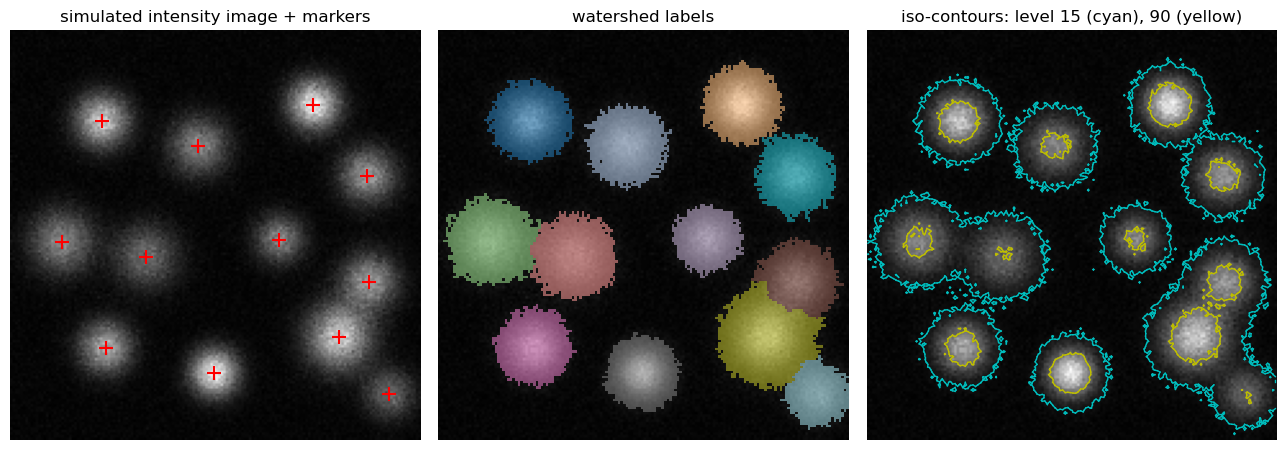

In [5]:
# Outlines
# --------
# The iso-contour at the mask level gives the outer boundary of the labelled
# area; a higher level outlines the bright cores. Segments come as
# ``(row0, col0, row1, col1)`` rows in raster order.
outline = np.asarray(tttrlib.marching_squares(image, 15.0, 0))
cores = np.asarray(tttrlib.marching_squares(image, 90.0, 0))
print(f"{outline.shape[0]} outline segments at level 15, {cores.shape[0]} core segments at level 90")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(image, cmap="gray")
axes[0].plot(centres[:, 1], centres[:, 0], "r+", ms=10, mew=1.5)
axes[0].set_title("simulated intensity image + markers")

masked = np.ma.masked_where(labels == 0, labels)
axes[1].imshow(image, cmap="gray")
axes[1].imshow(masked, cmap="tab20", alpha=0.55, interpolation="nearest")
axes[1].set_title("watershed labels")

axes[2].imshow(image, cmap="gray")
for r0, c0, r1, c1 in outline:
    axes[2].plot([c0, c1], [r0, r1], "c-", lw=1)
for r0, c0, r1, c1 in cores:
    axes[2].plot([c0, c1], [r0, r1], "y-", lw=1)
axes[2].set_title("iso-contours: level 15 (cyan), 90 (yellow)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [6]:
# Regions as ROIs
# ---------------
# The label image is what a per-region analysis indexes with: the summed
# intensity per cell, its area, or -- on a ``CLSMImage`` -- the decay of the
# photons that fall in it (``get_decay_of_pixels`` takes exactly such a mask).
areas = np.bincount(labels.ravel(), minlength=len(centres) + 1)[1:]
sums = np.bincount(labels.ravel(), weights=image.ravel(), minlength=len(centres) + 1)[1:]
for i, (a, s) in enumerate(zip(areas, sums)):
    print(f"region {i + 1:2d}: {a:4d} px, {s:8.0f} counts")

region  1:  806 px,    49025 counts
region  2:  794 px,    37627 counts
region  3:  764 px,    51693 counts
region  4:  954 px,    45179 counts
region  5:  880 px,    36734 counts
region  6:  559 px,    25534 counts
region  7:  692 px,    40349 counts
region  8:  716 px,    39312 counts
region  9:  676 px,    46008 counts
region 10: 1137 px,    75016 counts
region 11:  778 px,    39080 counts
region 12:  495 px,    20987 counts


In [7]:
# Connectivity and the ridge line
# -------------------------------
# With ``connectivity=1`` the flood walks faces only; with ``2`` also diagonals,
# so basins meet slightly differently along the ridges. The difference is a
# ridge-pixel matter, which is exactly where two touching cells are split.
labels8 = np.asarray(tttrlib.watershed(-image, markers, mask, 2))
print("pixels labelled differently with connectivity 2:", int((labels8 != labels).sum()))

pixels labelled differently with connectivity 2: 222
